# Visualise global and spatial effects of best environmental predictors


### imports

In [1]:

import sys
import os
import glob

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from cmocean.tools import lighten
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# statistics
import scipy as sci

# regridding package
import xesmf as xe

# Copernicus marine toolbox
#import copernicusmarine
#from pprint import pprint
#copernicusmarine.login()

# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("scipy version =", sci.__version__)
print("xarray version =", xr.__version__)
print("xesmf version =", xe.__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)

wrkdir="/g/data/es60/SEAPODYM/pearse_GAMs"
os.chdir(wrkdir)
os.getcwd()


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
scipy version = 1.15.3
xarray version = 2025.4.0
xesmf version = 0.8.10
cartopy version = 0.24.1
matplotlib version = 3.10.6
cmocean version = v3.0.3


'/g/data/es60/SEAPODYM/pearse_GAMs'

### Load dask cluster

In [2]:
from dask.distributed import Client, LocalCluster

# Rule of thumb here:
# - 56 workers × 1 thread each (good isolation for NumPy/xarray)
# - ~8 GB per worker → 56 * 8 = 448 GB (leaves headroom for OS, Jupyter, scheduler)
cluster = LocalCluster(
    n_workers=28,
    threads_per_worker=1,
    memory_limit="8GB",
    # Optional niceties:
    dashboard_address=":8787",   # or ":0" for random free port
    processes=True,
)

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 208.62 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38527,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38207,Total threads: 1
Dashboard: /proxy/42239/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:33575,


### load the global effects

In [2]:
%%time

global_TL1 = pd.read_csv("gam_FS5_global_T_L1.csv")
global_SST = pd.read_csv("gam_FS5_global_sst.csv")
global_UL3 = pd.read_csv("gam_FS5_global_U_L3.csv")
global_OL2 = pd.read_csv("gam_FS5_global_O2_L2.csv")
global_ZEU = pd.read_csv("gam_FS5_global_zeu.csv")
global_TL2 = pd.read_csv("gam_FS5_global_T_L2.csv")

def conv(y):
    x = y + 0.0
    x = np.sign(y) * (10**(np.abs(y)) - 1.0)
    return x

global_TL1['effect'] = conv(global_TL1['effect']) * 1e3
global_SST['effect'] = conv(global_SST['effect']) * 1e3
global_UL3['effect'] = conv(global_UL3['effect']) * 1e3
global_OL2['effect'] = conv(global_OL2['effect']) * 1e3
global_ZEU['effect'] = conv(global_ZEU['effect']) * 1e3
global_TL2['effect'] = conv(global_TL2['effect']) * 1e3

global_TL1['se'] = conv(global_TL1['se']) * 1e3
global_SST['se'] = conv(global_SST['se']) * 1e3
global_UL3['se'] = conv(global_UL3['se']) * 1e3
global_OL2['se'] = conv(global_OL2['se']) * 1e3
global_ZEU['se'] = conv(global_ZEU['se']) * 1e3
global_TL2['se'] = conv(global_TL2['se']) * 1e3


CPU times: user 38.2 ms, sys: 0 ns, total: 38.2 ms
Wall time: 225 ms


### plot the global relationships

CPU times: user 3.7 s, sys: 111 ms, total: 3.82 s
Wall time: 3.87 s


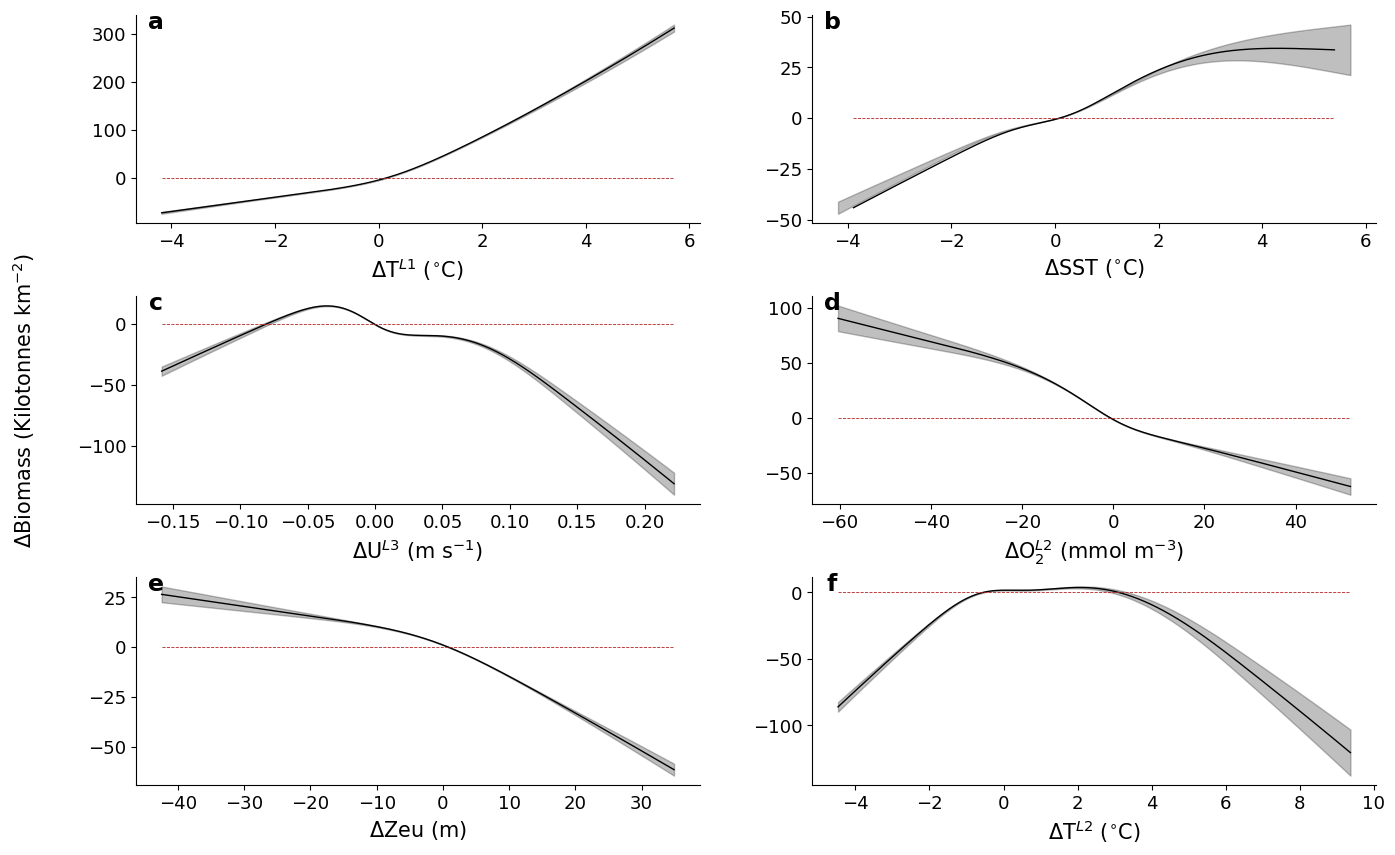

In [3]:
%%time

fstic = 13
fslab = 15

cols = ['k', 'firebrick']
lwid = [1.0, 0.6]
lsty = ['-', '--']
alfs = [1.0, 0.25]

fig = plt.figure(figsize=(16,10))
gs = GridSpec(3,2)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[1,0])
ax4 = plt.subplot(gs[1,1])
ax5 = plt.subplot(gs[2,0])
ax6 = plt.subplot(gs[2,1])

ax1.spines[['top','right']].set_visible(False)
ax2.spines[['top','right']].set_visible(False)
ax3.spines[['top','right']].set_visible(False)
ax4.spines[['top','right']].set_visible(False)
ax5.spines[['top','right']].set_visible(False)
ax6.spines[['top','right']].set_visible(False)
ax1.tick_params(labelsize=fstic)
ax2.tick_params(labelsize=fstic)
ax3.tick_params(labelsize=fstic)
ax4.tick_params(labelsize=fstic)
ax5.tick_params(labelsize=fstic)
ax6.tick_params(labelsize=fstic)

ax1.plot(global_TL1['x'], global_TL1['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax1.fill_between(global_TL1['x'], global_TL1['effect'] - global_TL1['se'], global_TL1['effect'] + global_TL1['se'], color=cols[0], alpha=alfs[1])
ax1.plot(global_TL1['x'],global_TL1['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax2.plot(global_SST['x'], global_SST['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax2.fill_between(global_TL1['x'], global_SST['effect'] - global_SST['se'], global_SST['effect'] + global_SST['se'], color=cols[0], alpha=alfs[1])
ax2.plot(global_SST['x'],global_SST['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax3.plot(global_UL3['x'], global_UL3['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax3.fill_between(global_UL3['x'], global_UL3['effect'] - global_UL3['se'], global_UL3['effect'] + global_UL3['se'], color=cols[0], alpha=alfs[1])
ax3.plot(global_UL3['x'],global_UL3['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax4.plot(global_OL2['x']*44.61, global_OL2['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax4.fill_between(global_OL2['x']*44.61, global_OL2['effect'] - global_OL2['se'], global_OL2['effect'] + global_OL2['se'], color=cols[0], alpha=alfs[1])
ax4.plot(global_OL2['x']*44.61,global_OL2['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax5.plot(global_ZEU['x'], global_ZEU['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax5.fill_between(global_ZEU['x'], global_ZEU['effect'] - global_ZEU['se'], global_ZEU['effect'] + global_ZEU['se'], color=cols[0], alpha=alfs[1])
ax5.plot(global_ZEU['x'],global_ZEU['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax6.plot(global_TL2['x'], global_TL2['effect'], color=cols[0], linewidth=lwid[0], linestyle=lsty[0], alpha=alfs[0])
ax6.fill_between(global_TL2['x'], global_TL2['effect'] - global_TL2['se'], global_TL2['effect'] + global_TL2['se'], color=cols[0], alpha=alfs[1])
ax6.plot(global_TL2['x'],global_TL2['x']*0.0, color=cols[1], linewidth=lwid[1], linestyle=lsty[1], alpha=alfs[0])

ax1.set_xlabel("$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab)
ax2.set_xlabel("$\Delta$SST ($^{\circ}$C)", fontsize=fslab)
ax3.set_xlabel("$\Delta$U$^{L3}$ (m s$^{-1}$)", fontsize=fslab)
ax4.set_xlabel("$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab)
ax5.set_xlabel("$\Delta$Zeu (m)", fontsize=fslab)
ax6.set_xlabel("$\Delta$T$^{L2}$ ($^{\circ}$C)", fontsize=fslab)

plt.subplots_adjust(hspace=0.35)

ax1.text(-0.2,0.5, "$\Delta$Biomass (Kilotonnes km$^{-2}$)", transform=ax3.transAxes, fontsize=fslab, va='center', ha='center', rotation=90)

xx = 0.035; yy = 0.965
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)

fig.savefig("./figures/Global_effects.png", dpi=300, bbox_inches='tight')
fig.savefig("./figures/Global_effects_transparent.png", dpi=300, bbox_inches='tight', transparent=True)


### Load the spatial effects data

In [4]:
%%time

spatial_TL1 = pd.read_csv("gam_FS5_spatial_T_L1_sd.csv")
spatial_SST = pd.read_csv("gam_FS5_spatial_sst_sd.csv")
spatial_UL3 = pd.read_csv("gam_FS5_spatial_U_L3_sd.csv")
spatial_OL2 = pd.read_csv("gam_FS5_spatial_O2_L2_sd.csv")
spatial_ZEU = pd.read_csv("gam_FS5_spatial_zeu_sd.csv")
spatial_TL2 = pd.read_csv("gam_FS5_spatial_T_L2_sd.csv")

#spatial_TL1 = pd.read_csv("gam_FS5_spatial_T_L1_0.5degC.csv")
#spatial_SST = pd.read_csv("gam_FS5_spatial_sst_0.5degC.csv")
#spatial_UL3 = pd.read_csv("gam_FS5_spatial_U_L3_0.025ms.csv")
#spatial_OL2 = pd.read_csv("gam_FS5_spatial_O2_L2_10mmolm3.csv")
#spatial_ZEU = pd.read_csv("gam_FS5_spatial_zeu_10m.csv")
#spatial_TL2 = pd.read_csv("gam_FS5_spatial_T_L2_0.5degC.csv")

def conv(y):
    x = y + 0.0
    x = np.sign(y) * (10**(np.abs(y)) - 1.0)
    return x

spatial_TL1['delta_eff'] = conv(spatial_TL1['delta_eff']) * 1e3
spatial_SST['delta_eff'] = conv(spatial_SST['delta_eff']) * 1e3
spatial_UL3['delta_eff'] = conv(spatial_UL3['delta_eff']) * 1e3
spatial_OL2['delta_eff'] = conv(spatial_OL2['delta_eff']) * 1e3
spatial_ZEU['delta_eff'] = conv(spatial_ZEU['delta_eff']) * 1e3
spatial_TL2['delta_eff'] = conv(spatial_TL2['delta_eff']) * 1e3

lons = spatial_TL1['lon']
lats = spatial_TL1['lat']
seasons = spatial_TL1['season_num']

spatial_TL1


CPU times: user 473 ms, sys: 136 ms, total: 609 ms
Wall time: 1.02 s


,lon,lat,season_num,delta_mult,delta_value,delta_eff
0,120.5,-0.5,2,-2,NaN,NaN
1,120.5,-0.5,4,-2,NaN,NaN
2,120.5,-0.5,1,-2,NaN,NaN
3,120.5,-0.5,3,-2,NaN,NaN
4,120.5,-1.5,1,-2,NaN,NaN
...,...,...,...,...,...,...
83195,249.5,8.5,3,2,1.665791,28.135510
83196,249.5,9.5,4,2,1.663338,48.672733
83197,249.5,9.5,3,2,1.663338,48.672733
83198,249.5,9.5,2,2,1.663338,48.672733


### turn the pandas Dataframe into an xarray Dataarray

In [5]:
%%time

ds_TL1 = (
    spatial_TL1
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_SST = (
    spatial_SST
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_UL3 = (
    spatial_UL3
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_OL2 = (
    spatial_OL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_ZEU = (
    spatial_ZEU
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

ds_TL2 = (
    spatial_TL2
    .set_index(['lon', 'lat', 'season_num', 'delta_mult'])
    .to_xarray()
)

lons = ds_TL1.coords['lon']
lats = ds_TL1.coords['lat']

ds_TL1


CPU times: user 98.4 ms, sys: 3.71 ms, total: 102 ms
Wall time: 100 ms


<xarray.Dataset> Size: 1MB
Dimensions:      (lon: 130, lat: 40, season_num: 4, delta_mult: 4)
Coordinates:
  * lon          (lon) float64 1kB 120.5 121.5 122.5 123.5 ... 247.5 248.5 249.5
  * lat          (lat) float64 320B -19.5 -18.5 -17.5 -16.5 ... 17.5 18.5 19.5
  * season_num   (season_num) int64 32B 1 2 3 4
  * delta_mult   (delta_mult) int64 32B -2 -1 1 2
Data variables:
    delta_value  (lon, lat, season_num, delta_mult) float64 666kB -1.007 ... ...
    delta_eff    (lon, lat, season_num, delta_mult) float64 666kB -201.9 ... ...

### visualise

/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 11.5 s, sys: 125 ms, total: 11.6 s
Wall time: 11.7 s


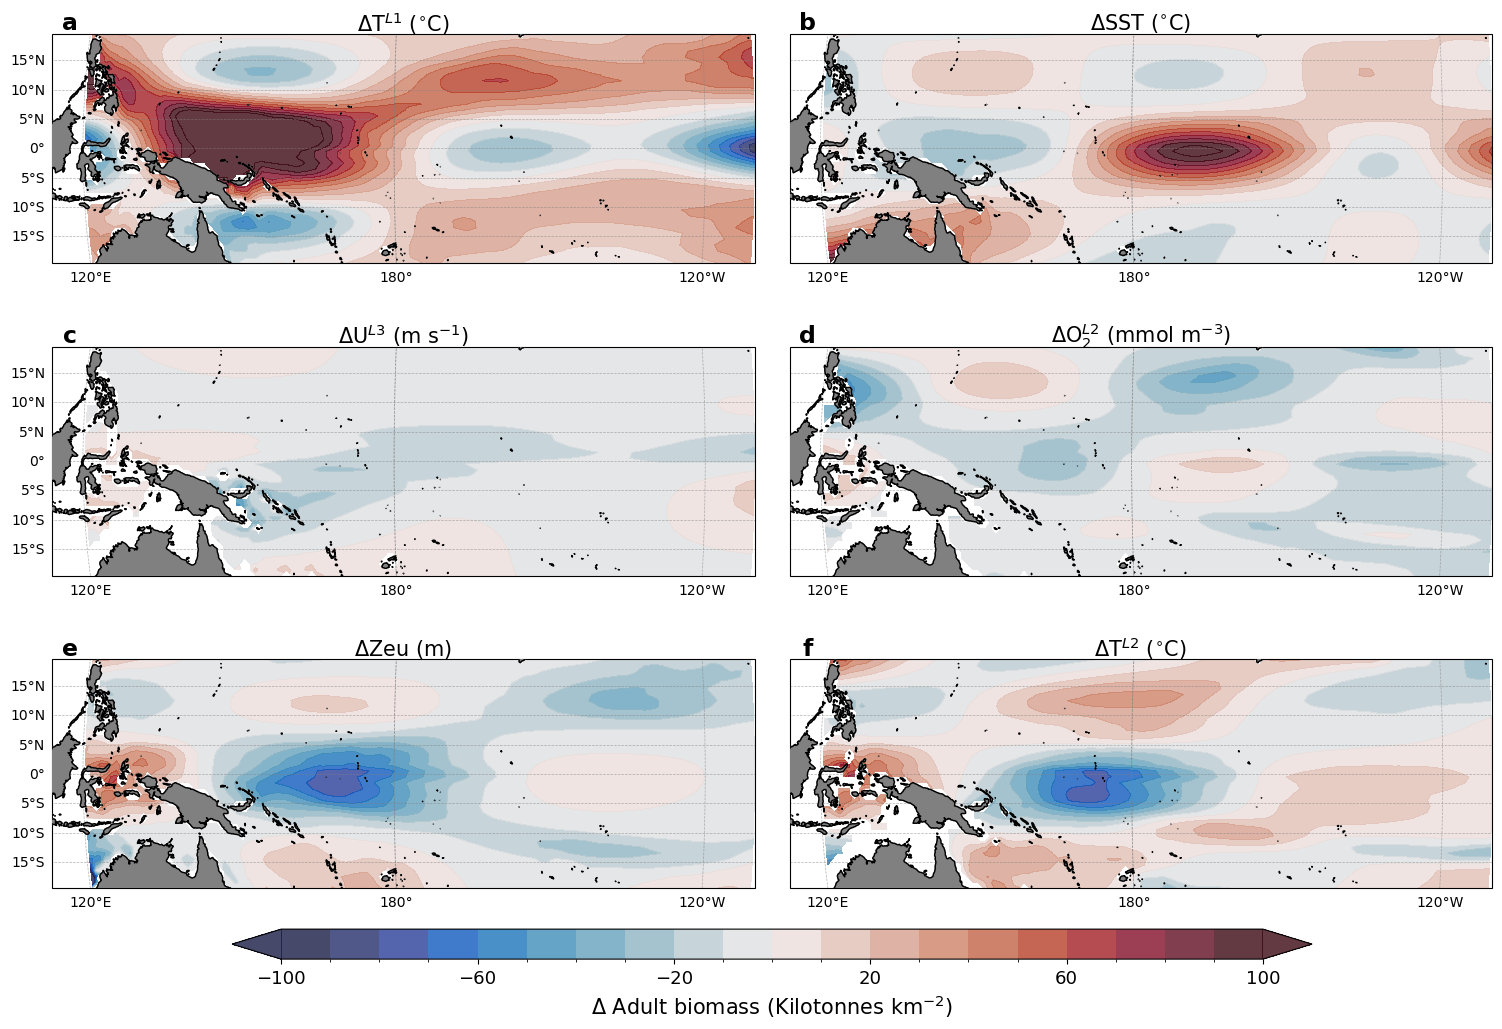

In [6]:
%%time

proj = ccrs.Robinson(central_longitude=205)

fstic = 13
fslab = 15

colmap = lighten(cmo.balance, 0.8)
levs = np.arange(-10,11,1)*10
norm = mcolors.BoundaryNorm(levs, ncolors=256)

fig = plt.figure(figsize=(18,12))
gs = GridSpec(3,2)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[1,0], projection=proj)
ax4 = plt.subplot(gs[1,1], projection=proj)
ax5 = plt.subplot(gs[2,0], projection=proj)
ax6 = plt.subplot(gs[2,1], projection=proj)

p1 = ax1.contourf(lons, lats, ds_TL1['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p2 = ax2.contourf(lons, lats, ds_SST['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p3 = ax3.contourf(lons, lats, ds_UL3['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p4 = ax4.contourf(lons, lats, ds_OL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p5 = ax5.contourf(lons, lats, ds_ZEU['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p6 = ax6.contourf(lons, lats, ds_TL2['delta_eff'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False

xx = 0.5; yy=1.05
plt.text(xx,yy,"$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy,"$\Delta$SST ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy,"$\Delta$U$^{L3}$ (m s$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy,"$\Delta$Zeu (m)", fontsize=fslab, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L2}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax6.transAxes)

plt.subplots_adjust(wspace=0.05, hspace=0.25, left=0.1, right=0.9, bottom=0.15)

cbax1 = fig.add_axes([0.2,0.1,0.6,0.025])
cbar1 = plt.colorbar(p1, cax=cbax1, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_xlabel("$\Delta$ Adult biomass (Kilotonnes km$^{-2}$)", fontsize=fslab)

xx = 0.025; yy = 1.05
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)

fig.savefig("./figures/Spatial_effects.png", dpi=300, bbox_inches='tight')



/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 11.1 s, sys: 133 ms, total: 11.3 s
Wall time: 11.3 s


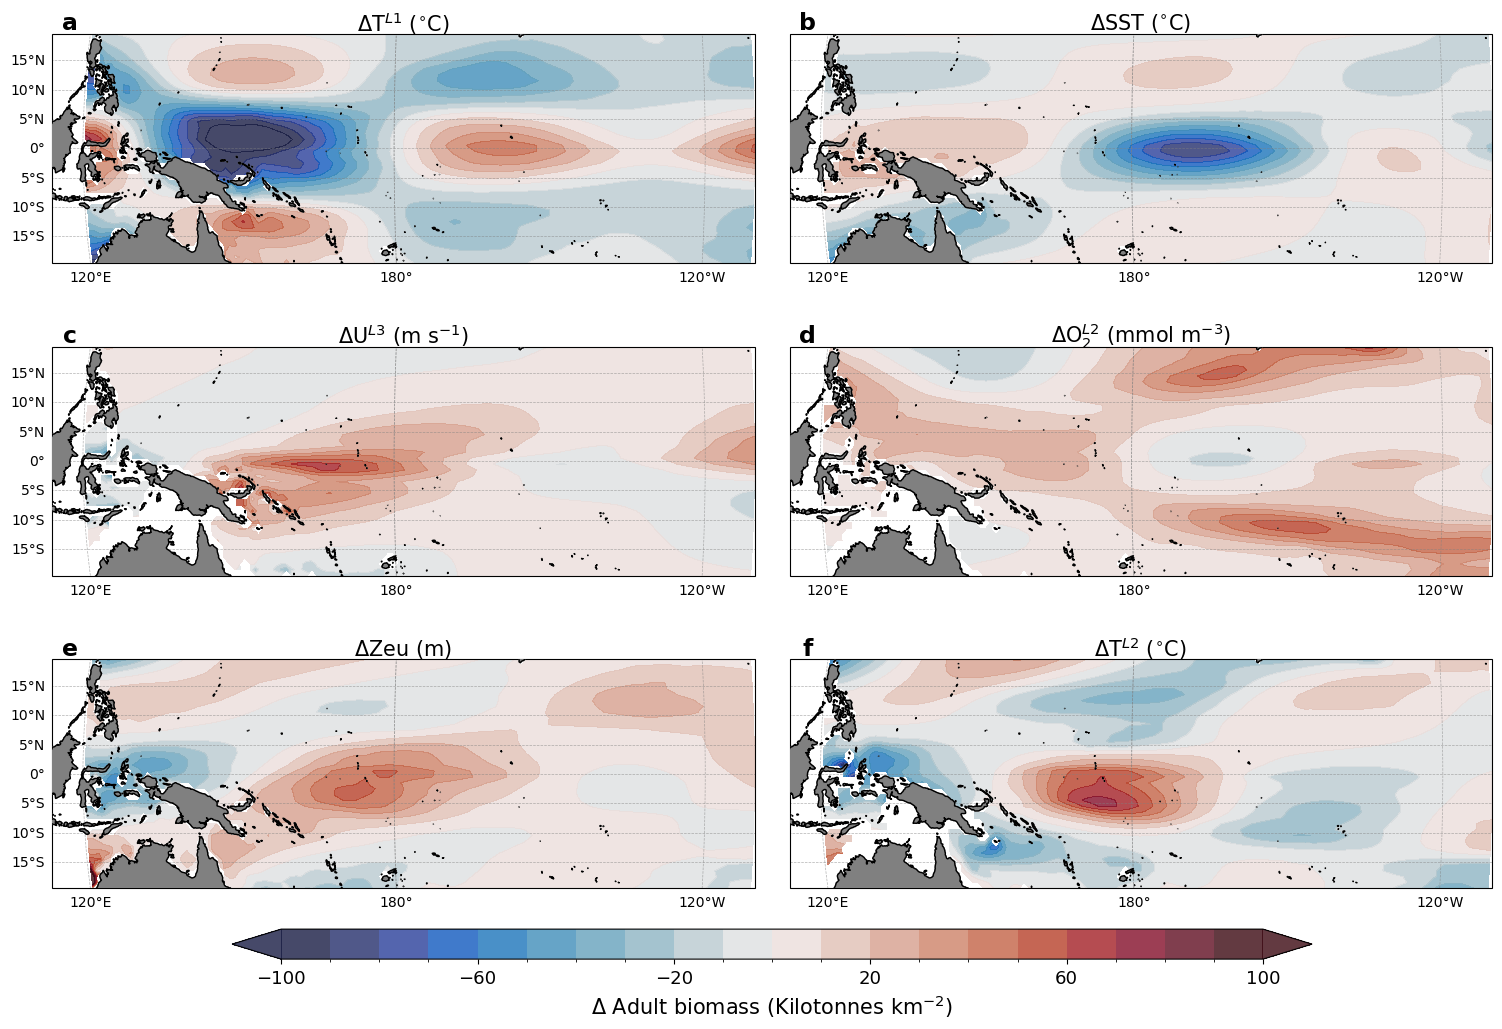

In [9]:
%%time

proj = ccrs.Robinson(central_longitude=205)

fstic = 13
fslab = 15

colmap = lighten(cmo.balance, 0.8)
levs = np.arange(-10,11,1)*10
norm = mcolors.BoundaryNorm(levs, ncolors=256)

fig = plt.figure(figsize=(18,12))
gs = GridSpec(3,2)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[1,0], projection=proj)
ax4 = plt.subplot(gs[1,1], projection=proj)
ax5 = plt.subplot(gs[2,0], projection=proj)
ax6 = plt.subplot(gs[2,1], projection=proj)

p1 = ax1.contourf(lons, lats, ds_TL1['delta_eff'].sel(delta_mult=-1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p2 = ax2.contourf(lons, lats, ds_SST['delta_eff'].sel(delta_mult=-1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p3 = ax3.contourf(lons, lats, ds_UL3['delta_eff'].sel(delta_mult=-1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p4 = ax4.contourf(lons, lats, ds_OL2['delta_eff'].sel(delta_mult=-1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p5 = ax5.contourf(lons, lats, ds_ZEU['delta_eff'].sel(delta_mult=-1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')
p6 = ax6.contourf(lons, lats, ds_TL2['delta_eff'].sel(delta_mult=-1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='both')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False

xx = 0.5; yy=1.05
plt.text(xx,yy,"$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy,"$\Delta$SST ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy,"$\Delta$U$^{L3}$ (m s$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy,"$\Delta$Zeu (m)", fontsize=fslab, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L2}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax6.transAxes)

plt.subplots_adjust(wspace=0.05, hspace=0.25, left=0.1, right=0.9, bottom=0.15)

cbax1 = fig.add_axes([0.2,0.1,0.6,0.025])
cbar1 = plt.colorbar(p1, cax=cbax1, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_xlabel("$\Delta$ Adult biomass (Kilotonnes km$^{-2}$)", fontsize=fslab)

xx = 0.025; yy = 1.05
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)

fig.savefig("./figures/Spatial_effects_m1STD.png", dpi=300, bbox_inches='tight')
fig.savefig("./figures/Spatial_effects_m1STD_transparent.png", dpi=300, bbox_inches='tight', transparent=True)



### Visualise the typical standard deviation of each predictor at each location

/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 13.2 s, sys: 138 ms, total: 13.3 s
Wall time: 13.3 s


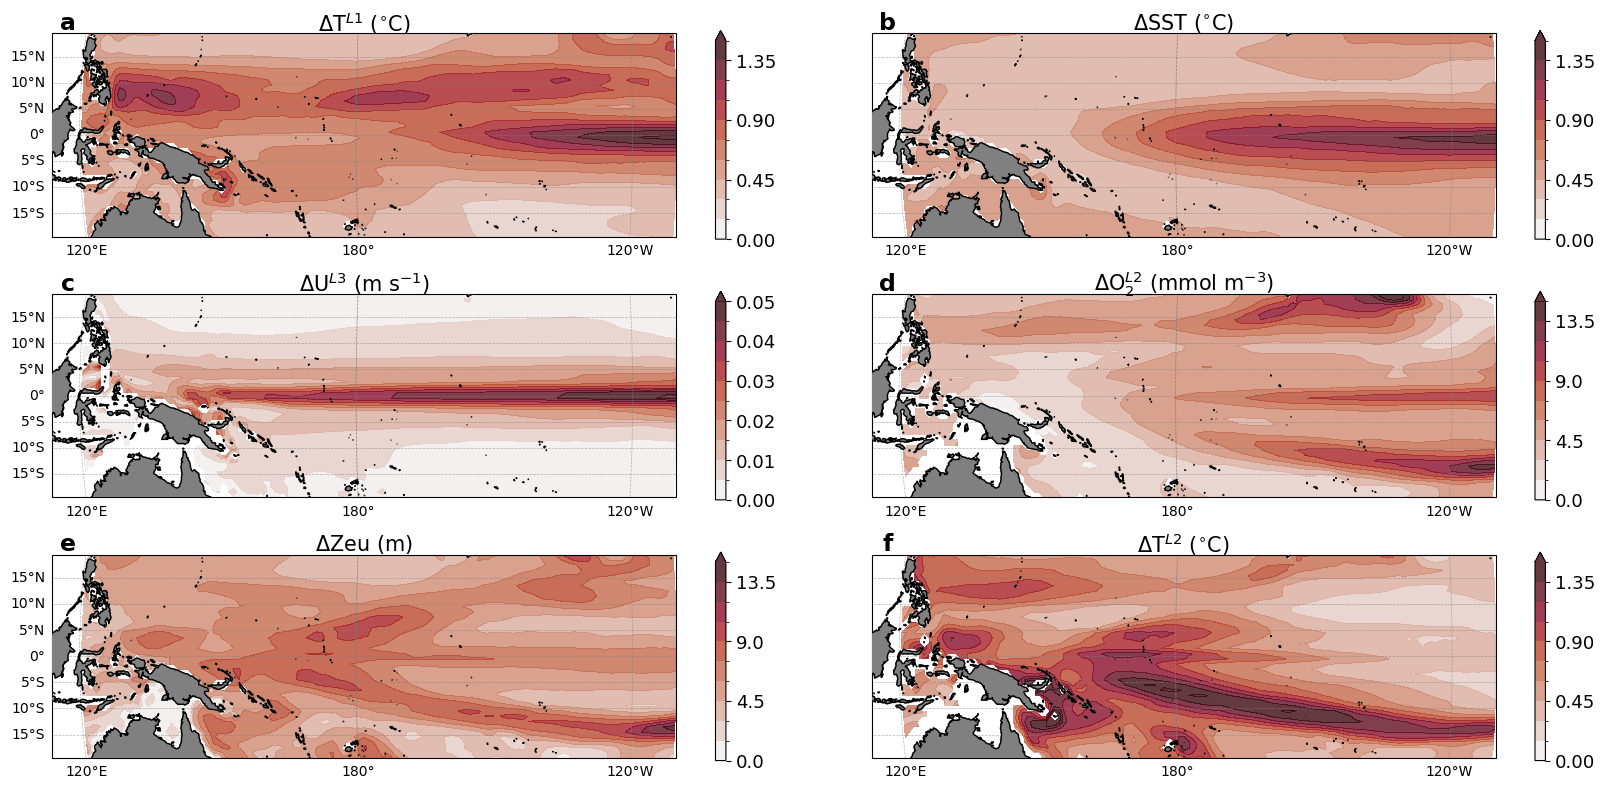

In [10]:
%%time

proj = ccrs.Robinson(central_longitude=205)

fstic = 13
fslab = 15

colmap = lighten(cmo.amp, 0.8)

levs1 = np.arange(0,11,1)*0.1*1.5
levs2 = np.arange(0,11,1)*0.1*1.5
levs3 = np.arange(0,11,1)*0.01*0.5
levs4 = np.arange(0,11,1)*1.0*1.5
levs5 = np.arange(0,11,1)*1.0*1.5
levs6 = np.arange(0,11,1)*0.1*1.5

norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)
norm3 = mcolors.BoundaryNorm(levs3, ncolors=256)
norm4 = mcolors.BoundaryNorm(levs4, ncolors=256)
norm5 = mcolors.BoundaryNorm(levs5, ncolors=256)
norm6 = mcolors.BoundaryNorm(levs6, ncolors=256)

fig = plt.figure(figsize=(20,10))
gs = GridSpec(3,2)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[1,0], projection=proj)
ax4 = plt.subplot(gs[1,1], projection=proj)
ax5 = plt.subplot(gs[2,0], projection=proj)
ax6 = plt.subplot(gs[2,1], projection=proj)

p1 = ax1.contourf(lons, lats, ds_TL1['delta_value'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='max')
p2 = ax2.contourf(lons, lats, ds_SST['delta_value'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='max')
p3 = ax3.contourf(lons, lats, ds_UL3['delta_value'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm3, levels=levs3, extend='max')
p4 = ax4.contourf(lons, lats, ds_OL2['delta_value'].sel(delta_mult=1).mean(dim='season_num').T * 44.661, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm4, levels=levs4, extend='max')
p5 = ax5.contourf(lons, lats, ds_ZEU['delta_value'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm5, levels=levs5, extend='max')
p6 = ax6.contourf(lons, lats, ds_TL2['delta_value'].sel(delta_mult=1).mean(dim='season_num').T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm6, levels=levs6, extend='max')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False

xx = 0.5; yy=1.05
plt.text(xx,yy,"$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy,"$\Delta$SST ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy,"$\Delta$U$^{L3}$ (m s$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy,"$\Delta$Zeu (m)", fontsize=fslab, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L2}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax6.transAxes)

plt.subplots_adjust(wspace=0.05, hspace=0.25, left=0.1, right=0.9, bottom=0.15)

cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::3])
cbar2 = plt.colorbar(p2, ax=ax2, orientation='vertical', ticks=levs2[::3])
cbar3 = plt.colorbar(p3, ax=ax3, orientation='vertical', ticks=levs3[::2])
cbar4 = plt.colorbar(p4, ax=ax4, orientation='vertical', ticks=levs4[::3])
cbar5 = plt.colorbar(p5, ax=ax5, orientation='vertical', ticks=levs5[::3])
cbar6 = plt.colorbar(p6, ax=ax6, orientation='vertical', ticks=levs6[::3])

cbar1.ax.tick_params(labelsize=fstic)
cbar2.ax.tick_params(labelsize=fstic)
cbar3.ax.tick_params(labelsize=fstic)
cbar4.ax.tick_params(labelsize=fstic)
cbar5.ax.tick_params(labelsize=fstic)
cbar6.ax.tick_params(labelsize=fstic)

#cbar1.ax.set_xlabel("$\Delta$ T$^{L1}$ ($^{\circ}$C)", fontsize=fslab)

xx = 0.025; yy = 1.05
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)

fig.savefig("./figures/Spatial_effects_predictorSTDs.png", dpi=300, bbox_inches='tight')
fig.savefig("./figures/Spatial_effects_predictorSTDs_transparent.png", dpi=300, bbox_inches='tight', transparent=True)



### Load SST and TL1 data

In [11]:
%%time

sst = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_sst_1958_2022.nc")['sst']
T_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_T_L1_1958_2022.nc")['T_L1']


CPU times: user 45.6 ms, sys: 15 ms, total: 60.7 ms
Wall time: 45 ms


### Check to see how these are correlated

In [12]:
%%time

r_sst_TL1 = xr.corr(sst, T_L1, dim='time')
r_sst_TL1


CPU times: user 944 ms, sys: 479 ms, total: 1.42 s
Wall time: 1.4 s


<xarray.DataArray (lat: 120, lon: 260)> Size: 125kB
array([[0.9272201 , 0.9220606 , 0.91796184, ..., 0.93997544, 0.93961877,
        0.9411042 ],
       [0.9499825 , 0.9447388 , 0.93915594, ..., 0.94372493, 0.9545399 ,
        0.9606822 ],
       [0.96426105, 0.96127075, 0.9574099 , ..., 0.96794116, 0.97314095,
        0.97758514],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(120, 260), dtype=float32)
Coordinates:
  * lon      (lon) float64 2kB 30.5 31.5 32.5 33.5 ... 286.5 287.5 288.5 289.5
  * lat      (lat) float64 960B -58.5 -57.5 -56.5 -55.5 ... 57.5 58.5 59.5 60.5

/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 2.9 s, sys: 503 ms, total: 3.41 s
Wall time: 2.83 s


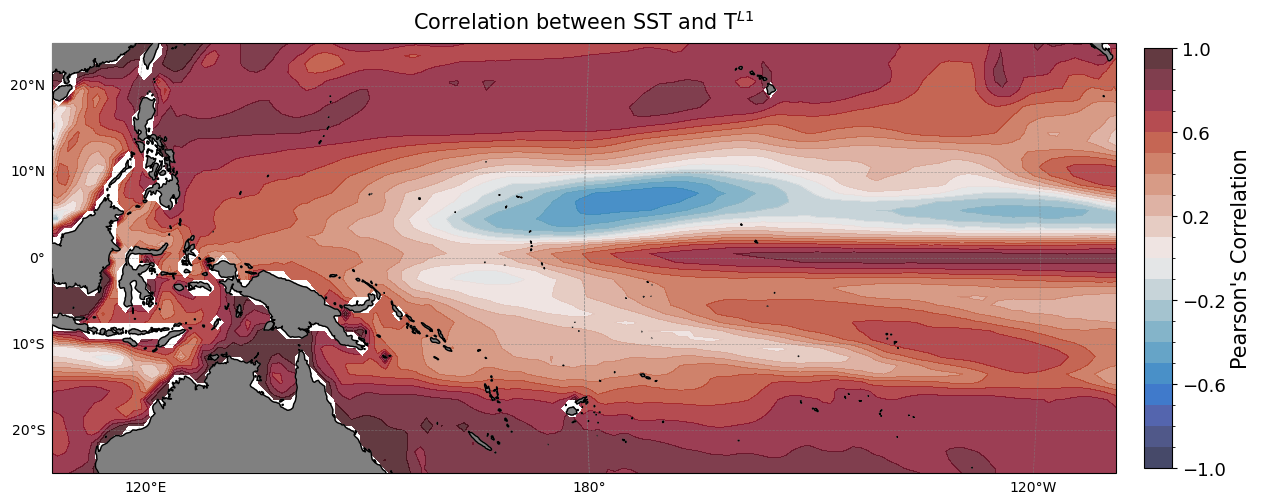

In [13]:
%%time

proj = ccrs.Robinson(central_longitude=205)
fstic = 13
fslab = 15
colmap = lighten(cmo.balance, 0.8)
levs1 = np.arange(-10,11,1)*0.1
norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)

fig = plt.figure(figsize=(14,6))
gs = GridSpec(1,1)
ax1 = plt.subplot(gs[0,0], projection=proj)
p1 = ax1.contourf(r_sst_TL1.coords['lon'], r_sst_TL1.coords['lat'], r_sst_TL1, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='neither')
ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl1.top_labels = False; gl1.right_labels = False

xx = 0.5; yy=1.05
plt.text(xx,yy,"Correlation between SST and T$^{L1}$", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.subplots_adjust(wspace=0.1, hspace=0.1, left=0.1, right=0.9, bottom=0.1)

cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::4], aspect=15, fraction=0.025, pad=0.025)
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_ylabel("Pearson's Correlation", fontsize=fslab)

ax1.set_extent([110,250,-25,25], crs=ccrs.PlateCarree())

fig.savefig("./figures/Correlation_SST_TL1.png", dpi=300, bbox_inches='tight')




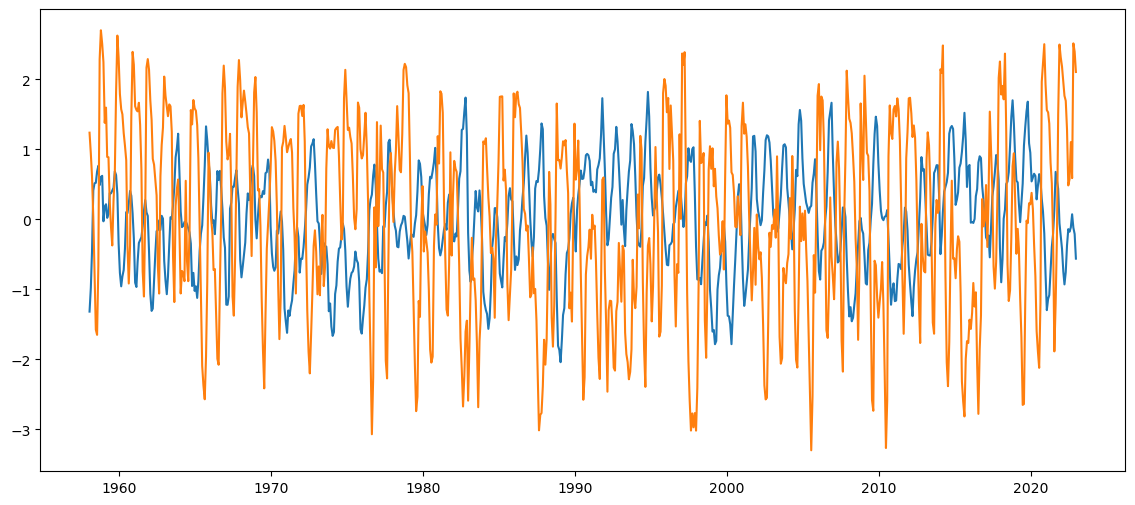

In [14]:
sst_tmp1 = sst.sel(lon=182.0, lat=5.0, method='nearest')
TL1_tmp1 = T_L1.sel(lon=182.0, lat=5.0, method='nearest')

plt.figure(figsize=(14,6))
plt.plot(sst.coords['time'], sst_tmp1 - sst_tmp1.mean(dim='time'))
plt.plot(T_L1.coords['time'], TL1_tmp1 - TL1_tmp1.mean(dim='time'))